In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('/content/drive/My Drive/A_Z Handwritten Data.csv').astype('float32')
df.head(5)

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.shape

(372450, 785)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372450 entries, 0 to 372449
Columns: 785 entries, 0 to 0.648
dtypes: float32(785)
memory usage: 1.1 GB


In [6]:
df.describe()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
count,372450.000000,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,...,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000
mean,13.523490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001616,0.001592,0.001117,0.000929,0.000685,0.000596,0.000618,0.000690,0.000239,0.000011
std,6.736685,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.490786,0.517295,0.421331,0.419179,0.385566,0.319819,0.208941,0.335227,0.134852,0.006554
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,14.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,18.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,25.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,252.000000,226.000000,229.000000,228.000000,235.000000,194.000000,103.000000,198.000000,82.000000,4.000000


In [8]:
data_array = np.array(df,dtype=np.uint8)
del df #to avoid memory issues

In [9]:
data_array.shape

(372450, 785)

In [10]:
alpha = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')

In [11]:
#splitting the data into labels and images then printing that data
labels = data_array[:,0]
x = data_array[:,1:].reshape(372450,28,28)/255.
del data_array
unique, counts = np.unique(labels, return_counts=True)
list_alpha = list(zip(alpha, counts))
for i in list_alpha:
    print(i[0],' : ',i[1])

A  :  13869
B  :  8668
C  :  23409
D  :  10134
E  :  11440
F  :  1163
G  :  5762
H  :  7218
I  :  1120
J  :  8493
K  :  5603
L  :  11586
M  :  12336
N  :  19010
O  :  57825
P  :  19341
Q  :  5812
R  :  11566
S  :  48419
T  :  22495
U  :  29008
V  :  4182
W  :  10784
X  :  6272
Y  :  10859
Z  :  6076


<BarContainer object of 26 artists>

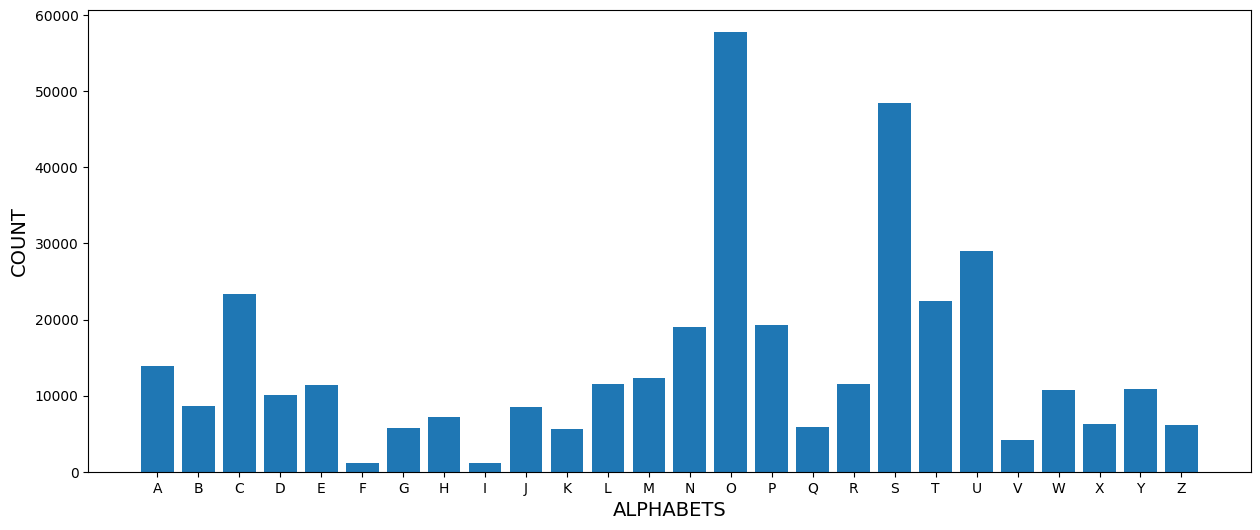

In [12]:
#visualizing the counts
fig=plt.figure(figsize=(15,6))
plt.xlabel('ALPHABETS',fontsize=14)
plt.ylabel('COUNT',fontsize=14)
plt.bar(alpha,counts)

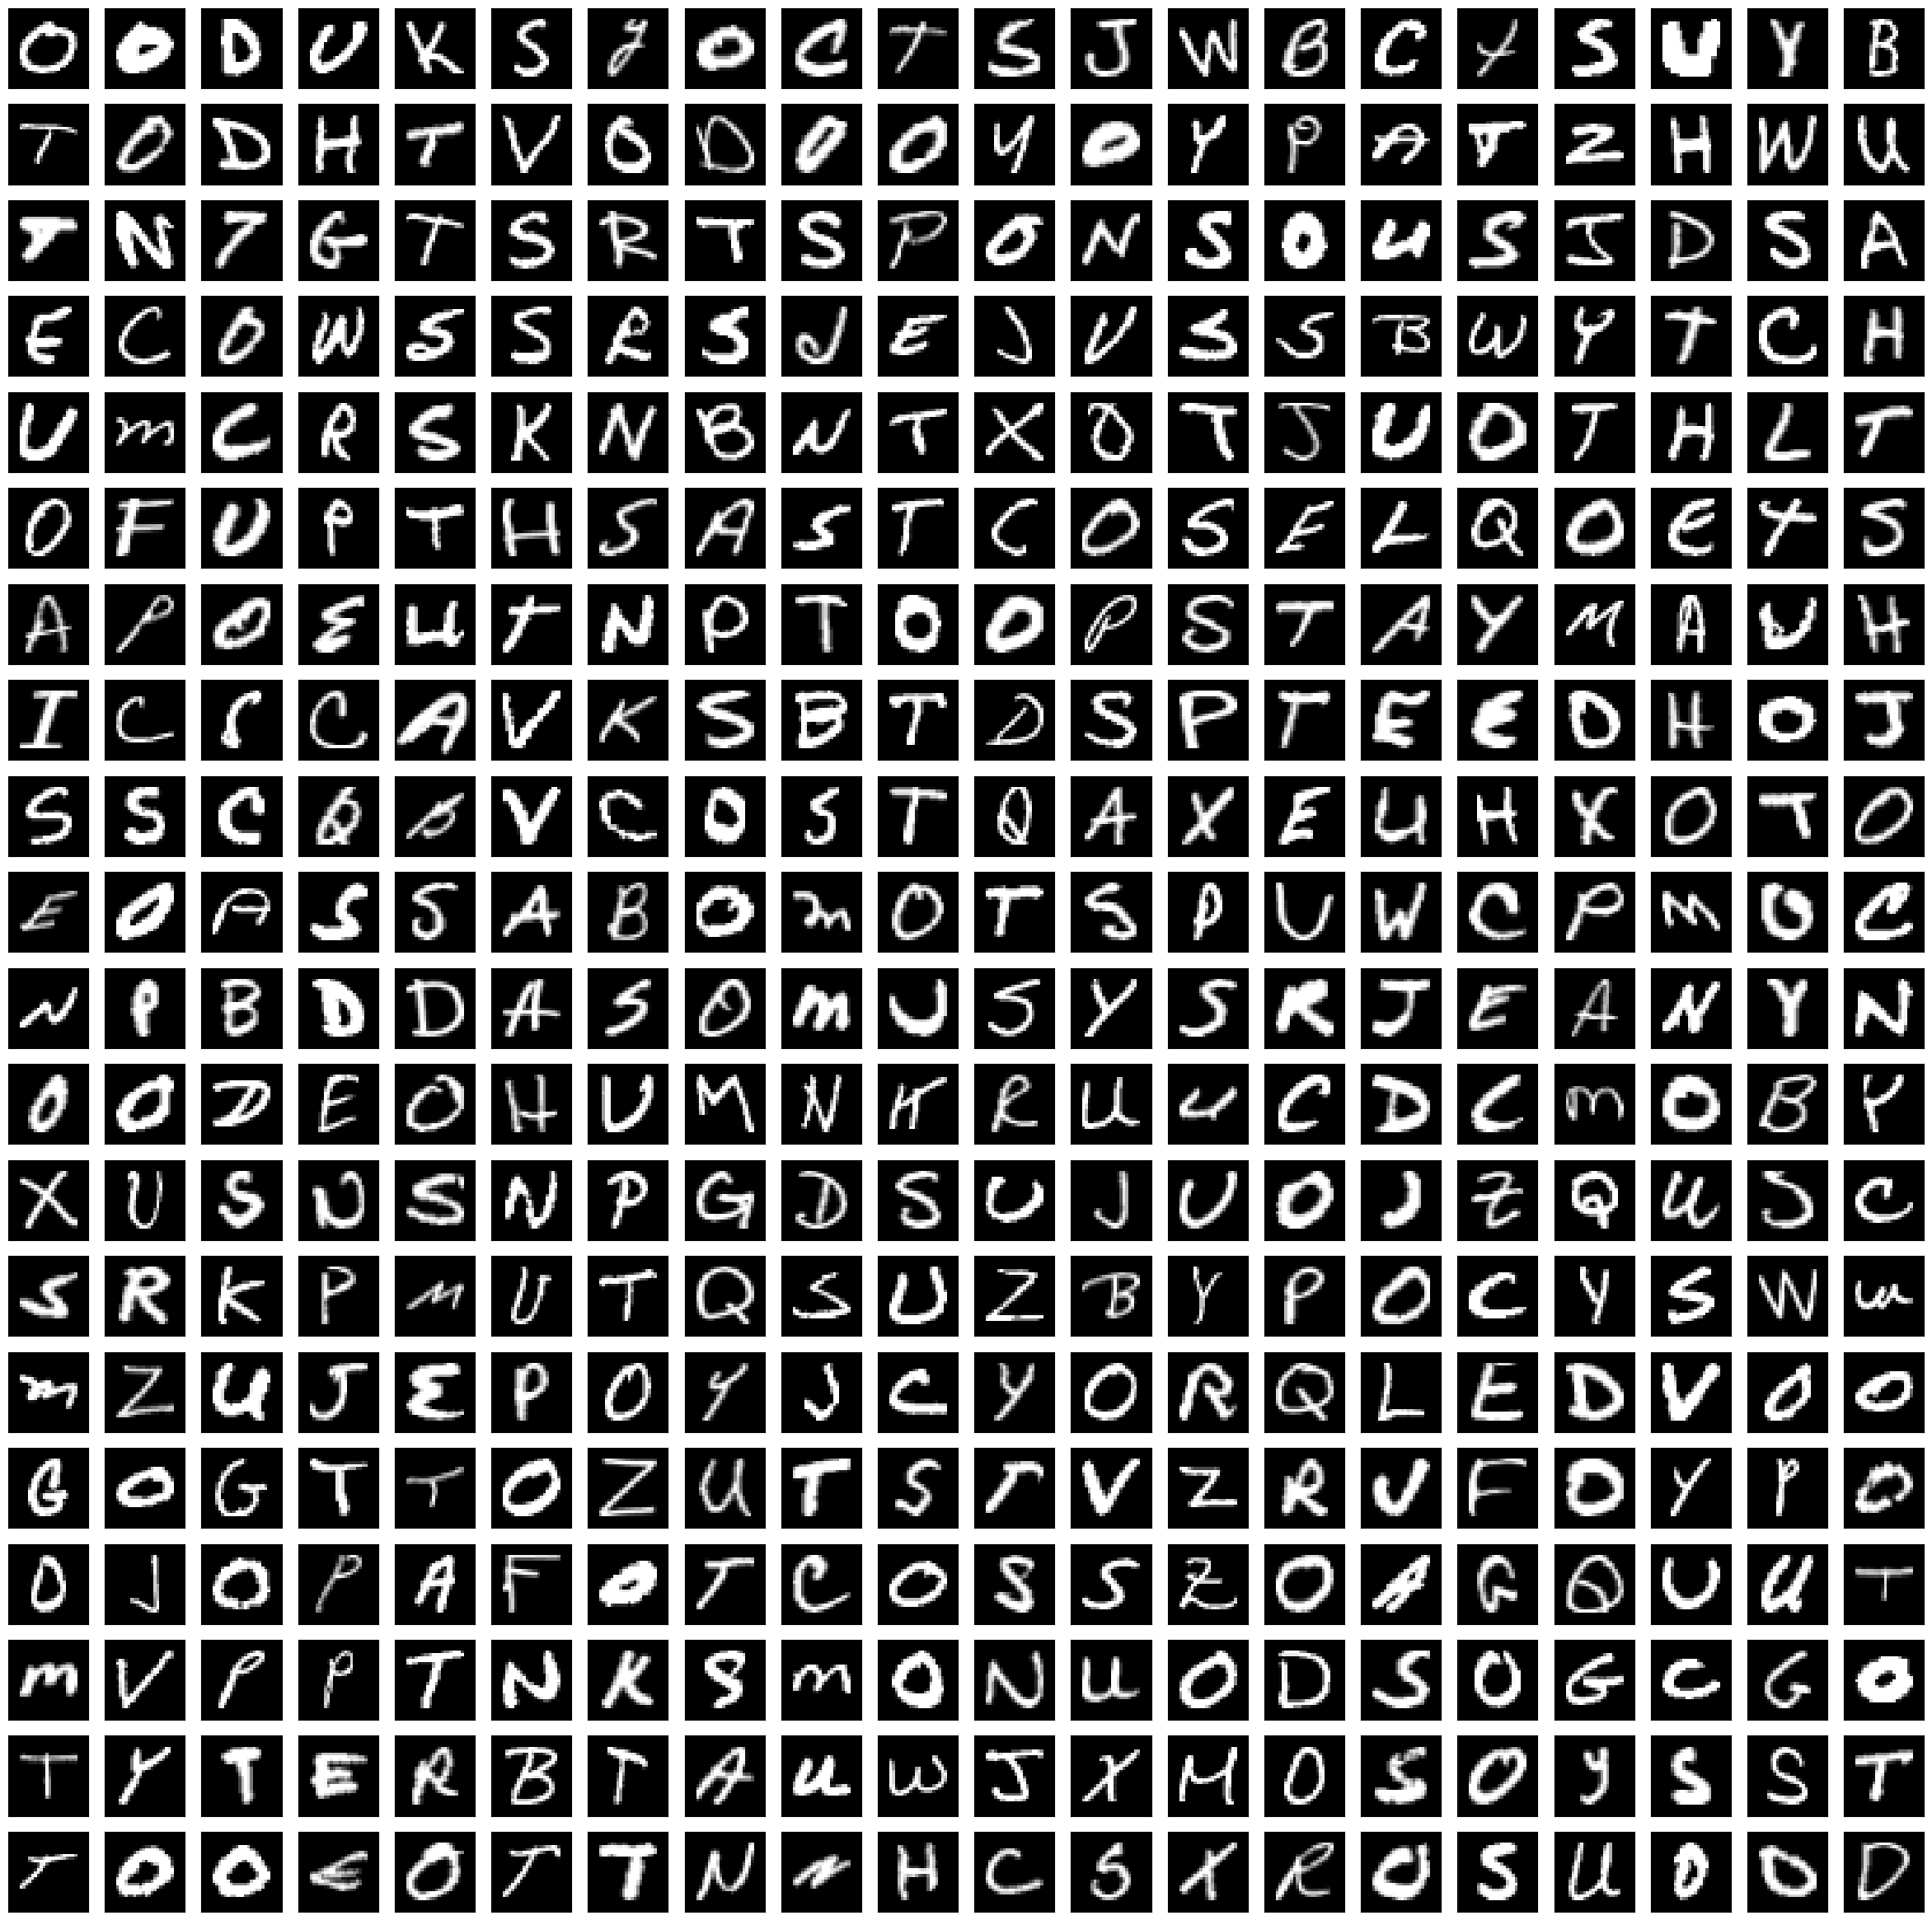

In [13]:
a=np.random.randint(low=0,high=372449,size=400)
fig=plt.figure(figsize=(30,30))
c=1
for i in a:
    fig.add_subplot(20,20,c)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x[i],cmap='gray')
    c+=1
del a

In [14]:
del c, list_alpha, counts, unique

Train Test split

In [15]:
from sklearn.model_selection import train_test_split as tts

In [16]:
x=x.reshape(372450,28,28,1)
x_train,x_test,y_train,y_test = tts(x,labels,test_size=0.01)
del x  # memory issues
del labels
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(368725, 28, 28, 1)
(3725, 28, 28, 1)
(368725,)
(3725,)


In [17]:
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dense,Dropout
from keras.layers import Flatten
from keras.layers import BatchNormalization
from keras.optimizers import Adadelta
from keras.optimizers import SGD
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [18]:
model = Sequential([
    Conv2D(128, (3,3), activation='relu', kernel_initializer='he_uniform', input_shape=(28,28,1), padding='same'),
    Conv2D(64, (3,3), activation='relu', kernel_initializer='he_uniform', padding='same'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu', kernel_initializer='he_uniform', padding='same'),
    Conv2D(64, (3,3), activation='relu', kernel_initializer='he_uniform', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(100, activation='relu', kernel_initializer='he_uniform'),
    Dropout(0.1),
    Dense(64, activation='relu', kernel_initializer='he_uniform'),
    Dropout(0.125),
    BatchNormalization(),
    Dense(26, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471,294 (1.80 MB)

 Trainable params: 471,038 (1.80 MB)

 Non-trainable params: 256 (1.00 KB)

In [19]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-4)

history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
2593/2593 ━━━━━━━━━━━━━━━━━━━━ 56s 19ms/step - accuracy: 0.9064 - loss: 0.3655 - val_accuracy: 0.9847 - val_loss: 0.0582 - learning_rate: 0.0100
Epoch 2/15
2593/2593 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.9827 - loss: 0.0636 - val_accuracy: 0.9886 - val_loss: 0.0448 - learning_rate: 0.0100
Epoch 3/15
2593/2593 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - accuracy: 0.9872 - loss: 0.0475 - val_accuracy: 0.9898 - val_loss: 0.0372 - learning_rate: 0.0100
Epoch 4/15
2593/2593 ━━━━━━━━━━━━━━━━━━━━ 82s 16ms/step - accuracy: 0.9898 - loss: 0.0365 - val_accuracy: 0.9903 - val_loss: 0.0362 - learning_rate: 0.0100
Epoch 5/15
2593/2593 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - accuracy: 0.9913 - loss: 0.0300 - val_accuracy: 0.9915 - val_loss: 0.0335 - learning_rate: 0.0100
Epoch 6/15
2593/2593 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - accuracy: 0.9928 - loss: 0.0255 - val_accuracy: 0.9925 - val_loss: 0.0282 - learning_rate: 0.0100
Epoch 7/15
2593/2593 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - accura

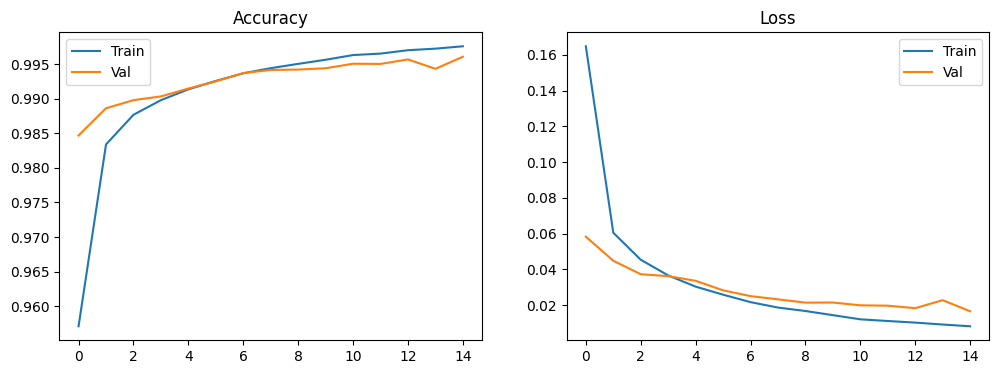

In [20]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()


In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict on the test set
y_pred = model.predict(x_test)
y_pred_labels = np.argmax(y_pred, axis=1)

# Generate classification report
report = classification_report(y_test, y_pred_labels, target_names=list('ABCDEFGHIJKLMNOPQRSTUVWXYZ'), output_dict=True)


117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


In [27]:
from sklearn.metrics import classification_report

# Assuming your classes are 0-25 for A-Z
target_names = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
report = classification_report(y_test, y_pred, target_names=target_names)
print(report)

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       144
           B       1.00      1.00      1.00        74
           C       1.00      1.00      1.00       229
           D       0.99      0.99      0.99       105
           E       1.00      1.00      1.00       123
           F       1.00      1.00      1.00        11
           G       1.00      0.98      0.99        42
           H       1.00      1.00      1.00        70
           I       1.00      1.00      1.00         8
           J       1.00      0.99      0.99        94
           K       1.00      1.00      1.00        62
           L       0.99      1.00      1.00       120
           M       0.99      1.00      1.00       110
           N       1.00      1.00      1.00       206
           O       1.00      1.00      1.00       573
           P       1.00      0.99      1.00       199
           Q       0.98      0.98      0.98        62
           R       1.00    

In [29]:
report_dict = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
report_df = pd.DataFrame(report_dict).T
# To display only class rows (not 'accuracy', 'macro avg', etc.)
class_metrics = report_df.iloc[:26][['precision', 'recall', 'f1-score', 'support']]
print(class_metrics)

   precision    recall  f1-score  support
A   1.000000  1.000000  1.000000    144.0
B   1.000000  1.000000  1.000000     74.0
C   1.000000  0.995633  0.997812    229.0
D   0.990476  0.990476  0.990476    105.0
E   1.000000  1.000000  1.000000    123.0
F   1.000000  1.000000  1.000000     11.0
G   1.000000  0.976190  0.987952     42.0
H   1.000000  1.000000  1.000000     70.0
I   1.000000  1.000000  1.000000      8.0
J   1.000000  0.989362  0.994652     94.0
K   1.000000  1.000000  1.000000     62.0
L   0.991736  1.000000  0.995851    120.0
M   0.990991  1.000000  0.995475    110.0
N   1.000000  0.995146  0.997567    206.0
O   0.996522  1.000000  0.998258    573.0
P   1.000000  0.994975  0.997481    199.0
Q   0.983871  0.983871  0.983871     62.0
R   1.000000  1.000000  1.000000    108.0
S   0.997877  1.000000  0.998937    470.0
T   1.000000  0.995781  0.997886    237.0
U   1.000000  1.000000  1.000000    281.0
V   0.978261  1.000000  0.989011     45.0
W   1.000000  0.990741  0.995349  

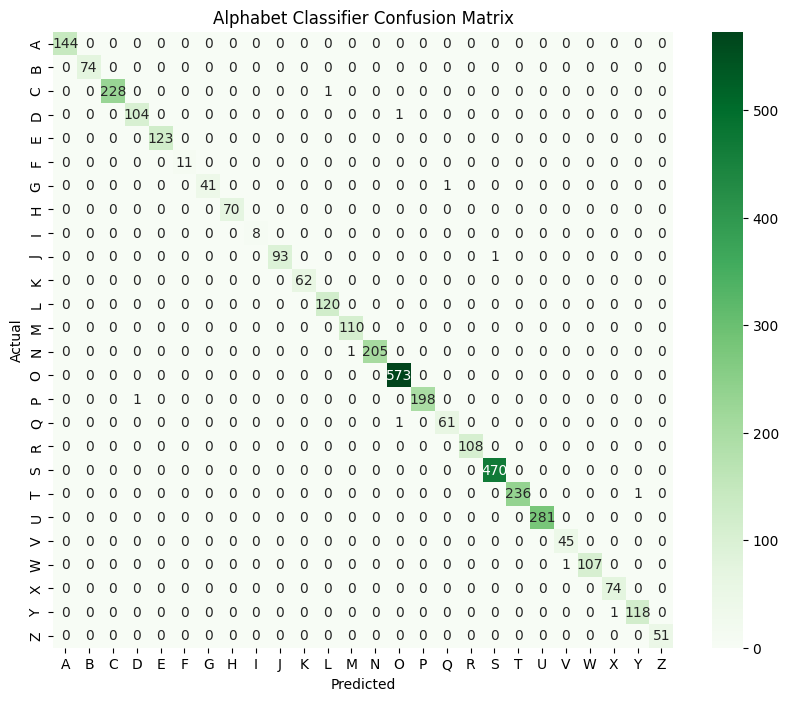

In [33]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Alphabet Classifier Confusion Matrix')
plt.show()

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print("Macro Avg:", report_df.loc['macro avg'][['precision', 'recall', 'f1-score']])
print("Weighted Avg:", report_df.loc['weighted avg'][['precision', 'recall', 'f1-score']])

Test Accuracy: 0.9973
Macro Avg: precision    0.996461
recall       0.996299
f1-score     0.996364
Name: macro avg, dtype: float64
Weighted Avg: precision    0.997332
recall       0.997315
f1-score     0.997315
Name: weighted avg, dtype: float64


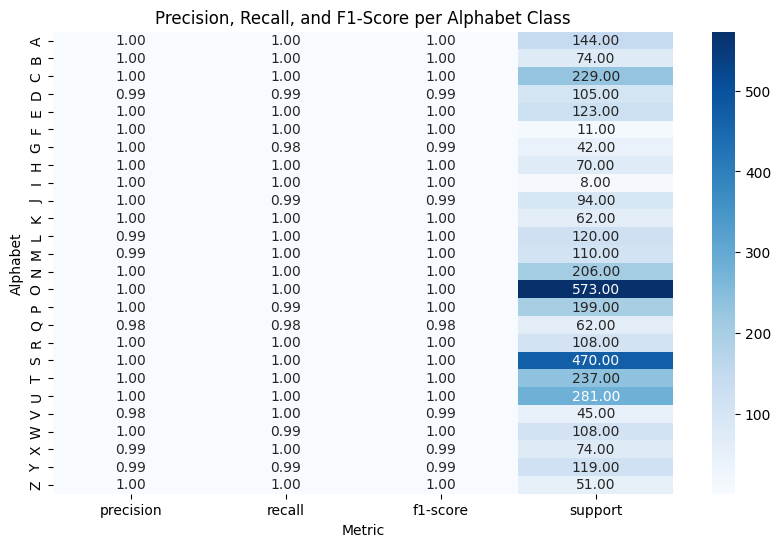

In [32]:
plt.figure(figsize=(10, 6))
sns.heatmap(class_metrics, annot=True, cmap='Blues', fmt=".2f")
plt.title('Precision, Recall, and F1-Score per Alphabet Class')
plt.xlabel('Metric')
plt.ylabel('Alphabet')
plt.show()
